In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.utils.data as data
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import copy

In [74]:
class RMSLELoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, y_pred, y_true):
        y_pred = torch.clamp(y_pred, min=0)
        log_pred = torch.log1p(y_pred)
        log_true = torch.log1p(y_true)
        return torch.sqrt(torch.mean((log_pred - log_true) ** 2))

In [75]:
def standardized_data(X_train, X_valid, X_test, numerical_cols=None):
    scaler = StandardScaler()
    if numerical_cols is not None:
        X_train_scaled = X_train.copy()
        X_valid_scaled = X_valid.copy()
        X_test_scaled = X_test.copy()
        X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
        X_valid_scaled[numerical_cols] = scaler.transform(X_valid[numerical_cols])
        X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])
    else:
        X_train_scaled = scaler.fit_transform(X_train)
        X_valid_scaled = scaler.transform(X_valid)
        X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_valid_scaled, X_test_scaled

Data transformation

In [ ]:
df = pd.read_csv("data.csv")

# df['mnth'] = df.apply(lambda row: np.sin((row['mnth']-4)*2*np.pi/12), axis=1)
# df['hr'] = df.apply(lambda row: np.sin((row['hr']-11)*2*np.pi/24), axis=1)
# # df["monthday"] = df.apply(lambda row: int(row["dteday"].split("-")[-1]), axis=1)
# df = df.drop(['instant','dteday', 'season'], axis=1)
df = df.drop(columns=["instant", "dteday"])
numerical_cols = ["temp", "atemp", "hum", "windspeed"]
df = df.astype(
    {
        "season": "int8",
        "hr": "int8",
        "holiday": "int8",
        "weekday": "int8",
        "workingday": "int8",
        "weathersit": "int8",
    }
)

df = df.reset_index(drop=True)
df

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,4,1,12,19,0,3,1,1,0.38,0.3939,0.50,0.3881,7,329,336
10882,4,1,12,20,0,3,1,1,0.36,0.3485,0.57,0.2239,10,231,241
10883,4,1,12,21,0,3,1,1,0.34,0.3182,0.61,0.2239,4,164,168
10884,4,1,12,22,0,3,1,1,0.34,0.3485,0.61,0.0896,12,117,129


Creating train valid and test dataset and standarizing data (only last column as label)

In [85]:
df=df.sample(frac=1, random_state=200)
train_size = int(0.6 * len(df))
valid_size = int(0.2 * len(df))
train = df[:train_size]
valid = df[train_size : train_size + valid_size]
test = df[train_size + valid_size :]
print(f"{train.shape=}")
print(f"{valid.shape=}")
print(f"{test.shape=}")

X_train = train.drop(columns=["casual","registered","cnt"])
y_train = train["cnt"]

X_valid = valid.drop(columns=["casual","registered","cnt"])
y_valid = valid["cnt"]

X_test = test.drop(columns=["casual","registered","cnt"])
y_test = test["cnt"]

X_train, X_valid, X_test = standardized_data(X_train, X_valid, X_test, numerical_cols)
print(f"{X_train.shape=}")
print(f"{X_valid.shape=}")
print(f"{X_test.shape=}")
print(f"{y_train.shape=}")
print(f"{y_valid.shape=}")
print(f"{y_test.shape=}")

train.shape=(6531, 15)
valid.shape=(2177, 15)
test.shape=(2178, 15)
X_train.shape=(6531, 12)
X_valid.shape=(2177, 12)
X_test.shape=(2178, 12)
y_train.shape=(6531,)
y_valid.shape=(2177,)
y_test.shape=(2178,)


In [86]:
train_dataset = data.TensorDataset(
    torch.from_numpy(X_train.values).float(), torch.from_numpy(y_train.values).long()
)
valid_dataset = data.TensorDataset(
    torch.from_numpy(X_valid.values).float(), torch.from_numpy(y_valid.values).long()
)
test_dataset = data.TensorDataset(
    torch.from_numpy(X_test.values).float(), torch.from_numpy(y_test.values).long()
)

Datasets are now ready
  
---

In [87]:
def create_model(model_class, num_inputs, num_hidden, num_outputs):
    return model_class(num_inputs=num_inputs, num_hidden=num_hidden, num_outputs=num_outputs)

In [88]:
class RegressionModel(nn.Module):

    def __init__(
        self, num_inputs, num_hidden1, num_hidden2, act_fn, num_outputs=1
    ):
        super().__init__()
        self.linear1 = nn.Linear(num_inputs, num_hidden1)
        self.act_fn = act_fn
        # self.norm2 = nn.BatchNorm1d(num_hidden)
        self.linear2 = nn.Linear(num_hidden1, num_hidden2)
        self.linear3 = nn.Linear(num_hidden2, num_outputs)

    def forward(self, x):
        x = self.linear1(x)
        x = self.act_fn(x)
        # x = self.norm2(x)
        x = self.linear2(x)
        x = self.act_fn(x)
        x = self.linear3(x)
        return x

In [89]:
def evaluate_model(model, dataset, loss_module):
    loader = data.DataLoader(dataset, batch_size=len(dataset), shuffle=False)
    model.eval()
    loss = 0

    with torch.no_grad():
        for x, y in loader:
            y = y.view(-1, 1).float()
            preds = model(x)
            loss += loss_module(preds, y).item()

    return loss

In [ ]:
def train_model(
    model,
    train_dataset,
    valid_dataset,
    batch_size,
    num_epochs,
    loss_module,
    optimizer,
    lr,
    lambda_reg,
    reg,
    verbose=0,
):
    print("--- TRAINING FOR PARAMS ---")
    print(
        f"model architecture:",
        [len(p) for idx, p in enumerate(model.parameters()) if idx % 2 == 0],
    )
    print(f"{model.act_fn=}")
    print(f"{batch_size=}")
    print(f"{num_epochs=}")
    print(f"{lr=}")
    print(f"{lambda_reg=}")
    print(f"{reg=}")
    print("-----------")

    train_loader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    optimizer = optimizer(model.parameters(), lr=lr)

    train_losses = []
    valid_losses = []

    best_val_loss = float("inf")
    best_model_state = None

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        n_samples = 0
        for x, y in train_loader:
            y = y.view(-1, 1).float()
            preds = model(x)
            loss = loss_module(preds, y)

            # L1 & L2 regularization
            if reg == 'L1':
                l1_reg = 0
                for param in model.parameters():
                    l1_reg += torch.sum(torch.abs(param))

                loss = loss + lambda_reg * l1_reg
            elif reg == 'L2':
                l2_reg = 0
                for param in model.parameters():
                    l2_reg += torch.sum(param ** 2)

                loss = loss + lambda_reg * l2_reg

            optimizer.zero_grad()
            loss.backward()
            # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item() * x.size(0)
            n_samples += x.size(0)

        train_loss = epoch_loss / n_samples
        train_losses.append(train_loss)
        val_loss = evaluate_model(model, valid_dataset, loss_module)
        valid_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())

        if verbose and (epoch + 1) % max(1, num_epochs // 10) == 0:
            print(
                f"Epoch {epoch+1}/{num_epochs} | "
                f"train_loss={train_loss:.4f} | "
                f"val_loss={val_loss:.4f}"
            )

    # wczytanie najlepszego modelu
    model.load_state_dict(best_model_state)

    plt.figure(figsize=(8,5))
    plt.plot(train_losses[30:], label="train")
    plt.plot(valid_losses[30:], label="valid")
    plt.legend()
    plt.title("Final training history")
    plt.show()

    return model, train_losses, valid_losses

--- TRAINING FOR PARAMS ---
model architecture: [512, 256, 1]
model.act_fn=SiLU()
batch_size=32
num_epochs=200
lr=0.01
lambda_reg=7e-06
reg='L1'
-----------
Epoch 20/200 | train_loss=0.4114 | val_loss=0.3768
Epoch 40/200 | train_loss=0.3381 | val_loss=0.3517
Epoch 60/200 | train_loss=0.3153 | val_loss=0.3206
Epoch 80/200 | train_loss=0.3068 | val_loss=0.3173
Epoch 100/200 | train_loss=0.2978 | val_loss=0.3194
Epoch 120/200 | train_loss=0.2969 | val_loss=0.3131
Epoch 140/200 | train_loss=0.2880 | val_loss=0.3174
Epoch 160/200 | train_loss=0.2889 | val_loss=0.3134
Epoch 180/200 | train_loss=0.2766 | val_loss=0.3310
Epoch 200/200 | train_loss=0.2739 | val_loss=0.3267


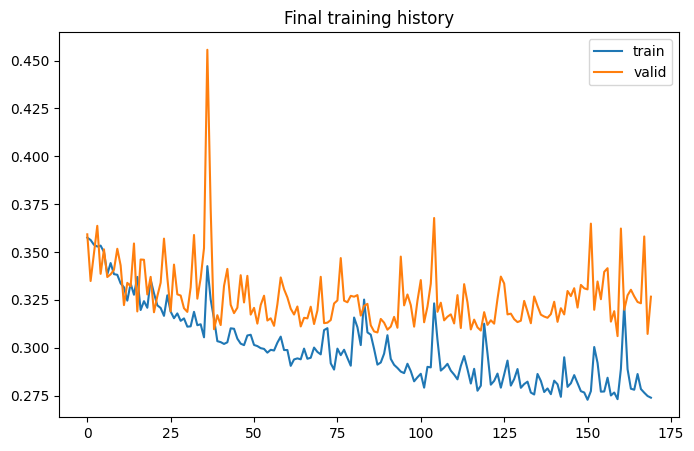

Best validation result:
0.3061


In [95]:
INPUT_SIZE = next(iter(train_dataset))[0].shape[0]
BATCH_SIZE = 32
LEARNING_RATE_OPTIMIZER = 0.01
OPTIMIZER = torch.optim.Adam
LOSS_MODULE = RMSLELoss()
NUM_EPOCHS = 200
OUTPUT_SIZE = 1
HIDDEN_SIZE_1 = 512
HIDDEN_SIZE_2 = 256
ACTIVATION_FUNCTION = nn.SiLU()
LAMBDA = 7e-6
REGULARIZATION = 'L1'

# more trainig with dropout, normalization...
model = RegressionModel(
    num_inputs=INPUT_SIZE,
    num_hidden1=HIDDEN_SIZE_1,
    num_hidden2=HIDDEN_SIZE_2,
    act_fn=ACTIVATION_FUNCTION,
    num_outputs=OUTPUT_SIZE,
)
model, train_losses, valid_losses = train_model(model, train_dataset, valid_dataset, batch_size=BATCH_SIZE, num_epochs=NUM_EPOCHS, loss_module=LOSS_MODULE, optimizer=OPTIMIZER, lr=LEARNING_RATE_OPTIMIZER, lambda_reg=LAMBDA, reg=REGULARIZATION, verbose=1)
print("Best validation result:")
print(f'{evaluate_model(model, valid_dataset, LOSS_MODULE):.4f}')

In [157]:
def generate_predictions(model, dataset, output_file="predictions.csv"):
    loader = data.DataLoader(dataset, batch_size=1, shuffle=False, drop_last=False)

    model.eval()
    preds_list = []

    with torch.no_grad():
        for data_inputs, _ in loader:
            preds = model(data_inputs)

            preds = preds.item()
            preds_list.append(preds)

    pd.Series(preds_list).to_csv(output_file, index=False, header=False)

    print(f"Saved {len(preds_list)} predictions to {output_file}")

In [140]:
model = RegressionModel(num_inputs=INPUT_SIZE, num_hidden=HIDDEN_SIZE, num_outputs=OUTPUT_SIZE)
train_model(
    model,
    train_dataset,
    batch_size=BATCH_SIZE,
    num_epochs=NUM_EPOCHS,
    loss_module=LOSS_MODULE,
    optimizer=OPTIMIZER,
    lr=LEARNING_RATE_OPTIMIZER,
    verbose=0,
)

RegressionModel(
  (linear1): Linear(in_features=11, out_features=64, bias=True)
  (act_fn): ReLU()
  (linear3): Linear(in_features=64, out_features=1, bias=True)
)

In [158]:
generate_predictions(model, train_dataset)

Saved 10777 predictions to predictions.csv
